import json- reads the COCO annotation file.

import os - works with folders and file paths.

import matplotlib.pyplot as plt - creates graphs and displays images.

from collections import Counter - counts repeated values easily.

In [33]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
dataset_path = "/content/drive/MyDrive/tomato_project/archive"

In [36]:
os.listdir(dataset_path)

['segmentation', 'detection']

In [37]:
segmentation_path = os.path.join(dataset_path, "segmentation")

In [38]:
os.listdir(segmentation_path)

['coco_annotations.json', 'labels', 'images']

In [39]:
annotation_file = os.path.join(segmentation_path, "coco_annotations.json")

In [40]:
with open(annotation_file, "r") as f:
  coco_data = json.load(f)

# Dataset Overview

In [41]:
coco_data.keys()

dict_keys(['images', 'annotations', 'categories'])

images - information about every image

annotations - every tomato annotation

categories - class names

In [42]:
print("Number of Images:", len(coco_data["images"]))
print("Number of Annotations:", len(coco_data["annotations"]))
print("Categories:", coco_data["categories"])

Number of Images: 177
Number of Annotations: 868
Categories: [{'id': 0, 'name': 'unripe', 'supercategory': 'tomato'}, {'id': 1, 'name': 'ripe', 'supercategory': 'tomato'}]


In [43]:
coco_data["images"][0]

{'id': 1, 'file_name': 'riped_tomato_10.jpeg', 'width': 250, 'height': 200}

In [44]:
coco_data["annotations"][0]

{'id': 1,
 'image_id': 1,
 'category_id': 0,
 'segmentation': [[182.0,
   61.0,
   173.0,
   56.00000000000001,
   163.0,
   55.00000000000001,
   162.0,
   54.0,
   155.0,
   54.0,
   154.0,
   55.00000000000001,
   147.0,
   55.00000000000001,
   139.0,
   57.99999999999999,
   132.0,
   57.99999999999999,
   131.0,
   59.0,
   128.0,
   59.0,
   127.0,
   60.0,
   119.0,
   62.0,
   113.0,
   66.0,
   107.0,
   76.0,
   107.0,
   78.0,
   105.0,
   82.0,
   105.0,
   87.0,
   104.0,
   88.0,
   105.0,
   101.0,
   109.0,
   109.00000000000001,
   109.0,
   111.00000000000001,
   113.0,
   115.99999999999999,
   113.0,
   119.0,
   116.0,
   121.0,
   117.0,
   123.0,
   121.0,
   126.0,
   121.0,
   127.0,
   122.0,
   126.0,
   125.0,
   129.0,
   126.0,
   128.0,
   129.0,
   130.0,
   134.0,
   128.0,
   137.0,
   130.0,
   140.0,
   130.0,
   141.0,
   129.0,
   143.0,
   130.0,
   144.0,
   129.0,
   148.0,
   129.0,
   149.0,
   128.0,
   150.0,
   129.0,
   154.0,
   129.0,
 

In [45]:
ripe = 0
unripe = 0

for annotation in coco_data["annotations"]:
  if annotation["category_id"] == 1:
    ripe += 1
  elif annotation["category_id"] == 0:
    unripe += 1

print("Ripe tomatoes: ", ripe)
print("Unripe tomatoes: ", unripe)

Ripe tomatoes:  429
Unripe tomatoes:  439


## Observation

The dataset contains 429 ripe tomato instances and 439 unripe tomato instances.

The difference between the two classes is only 10 samples, indicating that the dataset is well balanced.

A balanced dataset helps reduce bias during model training and allows evaluation metrics such as accuracy and F1-score to be interpreted more reliably.

In [46]:
image_ids = []
for annotation in coco_data["annotations"]:
  image_ids.append(annotation["image_id"])
image_counts = Counter(image_ids)
Counter(image_ids)


Counter({1: 3,
         2: 3,
         3: 3,
         4: 5,
         5: 12,
         6: 3,
         7: 4,
         8: 2,
         9: 8,
         10: 4,
         11: 15,
         12: 2,
         13: 3,
         14: 13,
         15: 3,
         16: 3,
         17: 1,
         18: 1,
         19: 3,
         20: 5,
         21: 1,
         22: 8,
         23: 5,
         24: 9,
         25: 11,
         26: 1,
         27: 3,
         28: 5,
         29: 4,
         30: 1,
         31: 2,
         32: 3,
         33: 4,
         34: 1,
         35: 3,
         36: 2,
         37: 3,
         38: 1,
         39: 4,
         40: 7,
         41: 2,
         42: 3,
         43: 5,
         44: 2,
         45: 17,
         46: 3,
         47: 6,
         48: 4,
         49: 14,
         50: 2,
         51: 2,
         52: 3,
         53: 8,
         54: 2,
         55: 3,
         56: 1,
         57: 3,
         58: 1,
         59: 4,
         60: 22,
         61: 5,
         62: 9,
         6

1. total numde rof images - 177

2. highest number of tomatoes present in one image - 22

3. average number of images - 868/177= 4.90, around 5 tomatoes per image.

The dataset consists of 177 images containing 868 annotated tomato instances. Each image contains between 1 and 22 tomatoes, with an average of approximately 4.9 tomatoes per image. This indicates that the dataset is composed predominantly of multi-object scenes, making it suitable for studying both object detection and instance-level classification.

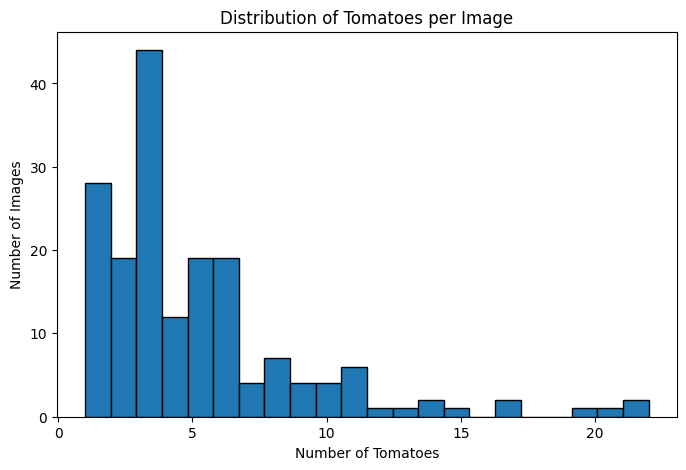

In [47]:
plt.figure(figsize=(8,5))
plt.hist(image_counts.values(), bins=22, edgecolor="black")
plt.title("Distribution of Tomatoes per Image")
plt.xlabel("Number of Tomatoes")
plt.ylabel("Number of Images")
plt.show()

This histogram shows the distribution of tomato instances per image. the x-axis represents the number of tomatoes present in an image, while the y-axis represents the number of images containing that many tomatoes.

#Displaying first image

In [48]:
image_folder = os.path.join(segmentation_path, "images")


In [49]:
image_files = sorted(os.listdir(image_folder))

print(image_files[0])

riped_tomato_1.jpeg


In [50]:
image_path = os.path.join(image_folder, image_files[0])

In [51]:
import cv2
image = cv2.imread(image_path)

In [52]:
type(image)

numpy.ndarray

In [53]:
image.shape

(256, 350, 3)

In [54]:
print(type(image))
print(image.shape)

<class 'numpy.ndarray'>
(256, 350, 3)


#Observation

Sample images in the dataset have varying resolutions. The first image has dimensions of 838 × 1000 pixels with three color channels, indicating that the dataset contains RGB color images (stored in BGR format by OpenCV).



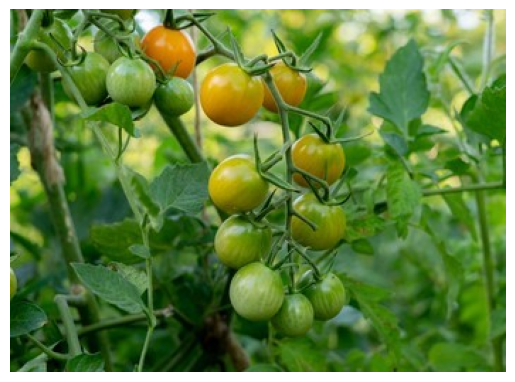

In [55]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

OpenCV stores images in BGR format, whereas Matplotlib expects RGB format. Therefore, images must be converted before visualization to ensure correct color representation.

#BOUNDING BOX VISUALISATION

#research Question

are the COCO annotations correctly marking every tomato in the dataset?

In [56]:
for image in coco_data["images"]:
  if image["file_name"] == image_files[0]:
    image_id = image["id"]
print(image_id)


11


In [57]:
print(image_files[0])

print(image_id)

riped_tomato_1.jpeg
11


In [58]:
for image in coco_data["images"]:
  if image["file_name"] == image_files[0]:
    image_id = image["id"]
    print(image)
print(image_id)

{'id': 11, 'file_name': 'riped_tomato_1.jpeg', 'width': 350, 'height': 256}
11


In [59]:
image_annotations = []

for annotation in coco_data["annotations"]:
    if annotation["image_id"] == image_id:
        image_annotations.append(annotation)
print(len(image_annotations))

15


In [60]:
print(image_annotations[0])

{'id': 48, 'image_id': 11, 'category_id': 1, 'segmentation': [[152.0001, 38.000128, 151.00015, 39.000064, 148.9999, 39.000064, 147.99994999999998, 40.0, 146.00005, 40.0, 145.0001, 40.999936, 144.00015, 40.999936, 141.9999, 43.000064, 140.99995, 43.000064, 138.0001, 46.000128, 138.0001, 47.000064, 135.99985, 48.999936, 135.99985, 49.999872, 134.9999, 51.000064, 134.9999, 52.999936, 133.99995, 54.000128, 133.99995, 65.999872, 134.9999, 67.000064, 134.9999, 68.999936, 135.99985, 70.000128, 135.99985, 72.0, 139.00005000000002, 75.000064, 139.00005000000002, 76.0, 140.99995, 78.000128, 141.9999, 78.000128, 144.00015, 80.0, 145.0001, 80.0, 146.00005, 80.999936, 147.99994999999998, 80.999936, 148.9999, 81.999872, 161.0, 81.999872, 161.99995, 80.999936, 163.99985, 80.999936, 165.00015, 80.0, 166.0001, 80.0, 168.0, 78.000128, 168.99994999999998, 78.000128, 173.0001, 73.999872, 173.0001, 72.999936, 175.0, 71.000064, 175.0, 70.000128, 176.9999, 68.0, 176.9999, 65.999872, 177.99985, 64.999936, 177

In [61]:
for annotation in image_annotations:

    bbox = annotation["bbox"]

    x, y, width, height = bbox

    start_point = (int(x), int(y))
    end_point = (int(x + width), int(y + height))

    if annotation["category_id"] == 1:
        color = (0, 255, 0)      # Green = ripe
    else:
        color = (255, 0, 0)      # Red = Unripe

    cv2.rectangle(image_rgb, start_point, end_point, color, 2)

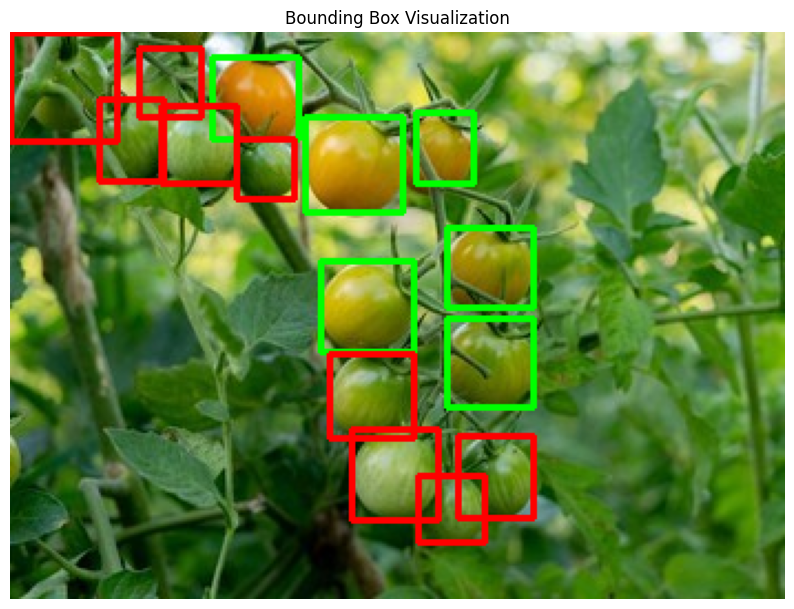

In [62]:
plt.figure(figsize=(10,8))
plt.imshow(image_rgb)
plt.title("Bounding Box Visualization")
plt.axis("off")
plt.show()

#Observation:



*   A total of 15 tomatoes were detected in the selected image.
*   Green bounding boxes represen tripe tomatoes, while red bounding boxes represent unripe tomatoes.
*   The annotations correctly localize each tomato, indicating that the dataset is well-annotated.
*   Bounding boxes provide object localization but do not capture the exact shape of the tomatoes.






#SEGMENTATION MASK VISUALIZATION

#Research Question

how does segmentation provide more detailed object information comapared to bounding boxes?

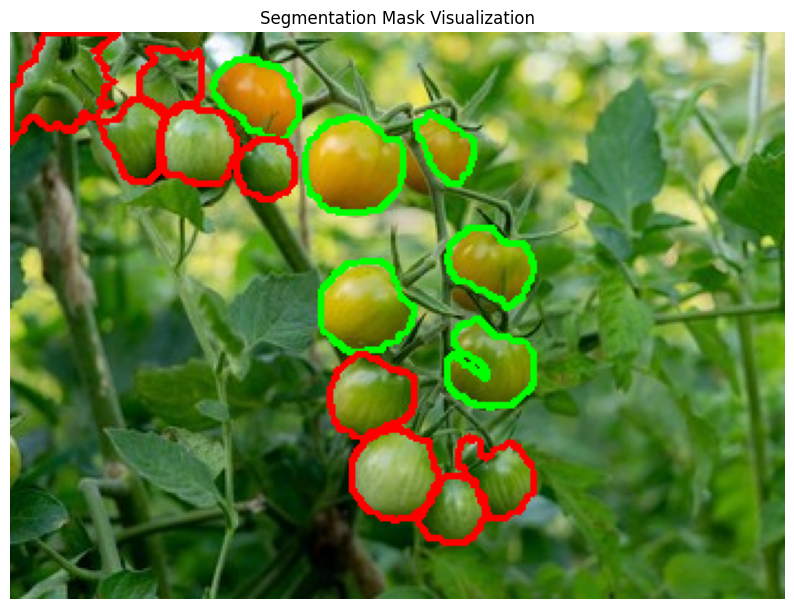

In [65]:
# Reload the original image
image = cv2.imread(os.path.join(image_folder, image_files[0]))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Now draw segmentation masks
for annotation in image_annotations:

    segmentation = annotation["segmentation"]

    points = np.array(segmentation[0]).reshape((-1, 2))
    points = points.astype(int)

    if annotation["category_id"] == 1:
        color = (0, 255, 0)
    else:
        color = (255, 0, 0)

    cv2.polylines(image_rgb, [points], True, color, 2)

plt.figure(figsize=(10,8))
plt.imshow(image_rgb)
plt.title("Segmentation Mask Visualization")
plt.axis("off")
plt.show()

In [66]:
areas = []

for annotation in coco_data["annotations"]:

    bbox = annotation["bbox"]

    x, y, width, height = bbox

    area = width * height

    areas.append(area)

In [67]:
average_area = sum(areas) / len(areas)
print(f"Average Tomato Area: {average_area:.2f} pixels²")

Average Tomato Area: 267267.45 pixels²


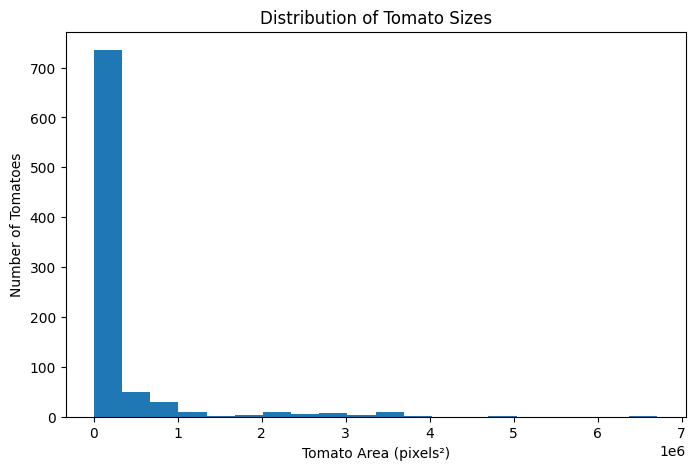

In [68]:
plt.figure(figsize=(8,5))

plt.hist(areas, bins=20)

plt.title("Distribution of Tomato Sizes")
plt.xlabel("Tomato Area (pixels²)")
plt.ylabel("Number of Tomatoes")

plt.show()

###Observation:
The histogram shows the distribution of tomato sizes based on the bounding box area. Most tomatoes are concentrated within a certain size range, while a few may appear significantly smaller or larger. This information helps understand the variability in object sizes within the dataset and can guide preprocessing or model training decisions.


#IMAGE RESOLUTION ANALYSIS

In [73]:
widths = []
heights = []

for image in coco_data["images"]:
    widths.append(image["width"])
    heights.append(image["height"])

# Calculate average width and height
average_width = sum(widths) / len(widths)
average_height = sum(heights) / len(heights)

# Print statistics
print(f"Average Width: {average_width:.2f} pixels")
print(f"Average Height: {average_height:.2f} pixels")

print(f"Minimum Width: {min(widths)} pixels")
print(f"Maximum Width: {max(widths)} pixels")

print(f"Minimum Height: {min(heights)} pixels")
print(f"Maximum Height: {max(heights)} pixels")

Average Width: 1374.88 pixels
Average Height: 991.36 pixels
Minimum Width: 250 pixels
Maximum Width: 7792 pixels
Minimum Height: 200 pixels
Maximum Height: 5200 pixels


#Distribution of image widths

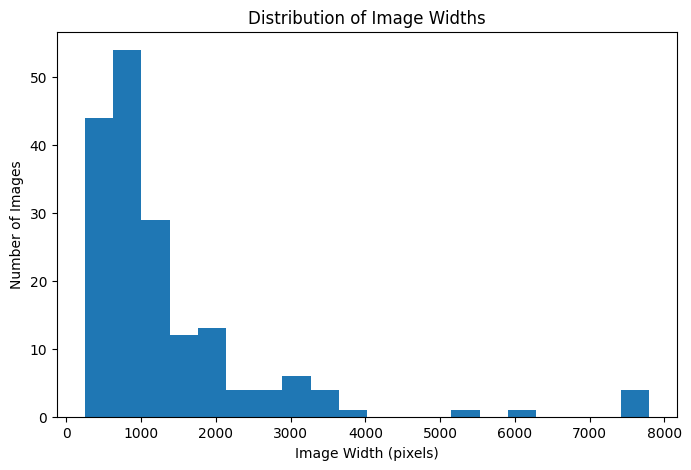

In [74]:
plt.figure(figsize=(8,5))
plt.hist(widths, bins=20)
plt.title("Distribution of Image Widths")
plt.xlabel("Image Width (pixels)")
plt.ylabel("Number of Images")
plt.show()

#Distribution of Image Heights

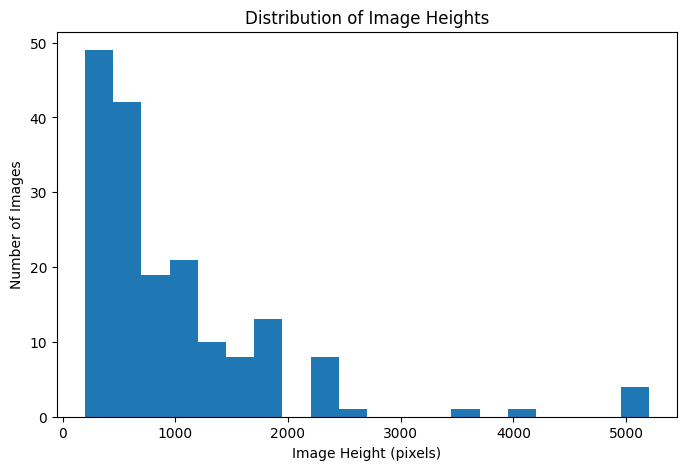

In [75]:
plt.figure(figsize=(8,5))
plt.hist(heights, bins=20)
plt.title("Distribution of Image Heights")
plt.xlabel("Image Height (pixels)")
plt.ylabel("Number of Images")
plt.show()

### Observation

The image resolution analysis shows the variation in image widths and heights across the dataset. The average image dimensions provide an estimate of the typical image size, while the minimum and maximum values indicate the range of resolutions. Since the images are not of identical dimensions, resizing will be required during the preprocessing stage before training the segmentation model.

#DATASET SUMMARY


In [78]:

from collections import Counter

image_ids = []

for annotation in coco_data["annotations"]:
    image_ids.append(annotation["image_id"])

image_counter = Counter(image_ids)

total_images = len(coco_data["images"])
total_tomatoes = len(coco_data["annotations"])

average_tomatoes = total_tomatoes / total_images

print("="*50)
print("        DATASET SUMMARY")
print("="*50)

print(f"Total Images                : {total_images}")
print(f"Total Tomatoes              : {total_tomatoes}")
print(f"Ripe Tomatoes               : {ripe}")
print(f"Unripe Tomatoes             : {unripe}")
print(f"Average Tomatoes/Image      : {average_tomatoes:.2f}")
print(f"Maximum Tomatoes/Image      : {max(image_counter.values())}")
print(f"Minimum Tomatoes/Image      : {min(image_counter.values())}")
print(f"Average Tomato Area         : {average_area:.2f} pixels²")
print(f"Average Image Width         : {average_width:.2f} pixels")
print(f"Average Image Height        : {average_height:.2f} pixels")

print("="*50)

        DATASET SUMMARY
Total Images                : 177
Total Tomatoes              : 868
Ripe Tomatoes               : 429
Unripe Tomatoes             : 439
Average Tomatoes/Image      : 4.90
Maximum Tomatoes/Image      : 22
Minimum Tomatoes/Image      : 1
Average Tomato Area         : 267267.45 pixels²
Average Image Width         : 1374.88 pixels
Average Image Height        : 991.36 pixels
